# XGBoost Model: YouTube Trending Prediction
Train and evaluate XGBoost classifier on df_ml dataset

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 3.1.2


## 2. Load Dataset

In [2]:
# Note: adjust path if your working directory differs
DATA_PATH = "./data/ml_dataset.csv"
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['is_trending'].value_counts())
print(f"Trending rate: {df['is_trending'].mean()*100:.1f}%")

Shape: (158073, 11)

Target distribution:
is_trending
False    117310
True      40763
Name: count, dtype: int64
Trending rate: 25.8%


In [3]:
df

,video_id,channel_id,subscriber_count,view_count,video_count,like_rate,comment_rate,duration_seconds,topic,country_region,is_trending
0,---k1vFBbWw,UCpQ34afVgk8cRQBjSJ1xuJQ,11400000,1617557672,1385,0.023100,0.000329,809,fitness,North America,False
1,--0NZjUvuKs,UCgmdMwVR6MLaJOLgE6c1q7Q,350000,757675886,2266,0.060768,0.001169,63,entertainment,North America,False
2,--ASSQxzhPE,UCwQy5xNCIjlpK6wUqUMEHeA,523000,27968101,144,0.019459,0.000344,57,gaming,Southeast Asia,False
3,--Avak9eZ_0,UCxaZ0oJZJlRQ8wQihzwzsWg,556000,83566008,242,0.077687,0.000089,3625,kids,North America,False
4,--CKzGfPWn0,UCAj9nn-gOcKuD4ropg44HCw,1250000,369421974,425,0.009087,0.000148,4324,music,Western Europe,False
...,...,...,...,...,...,...,...,...,...,...,...
158068,zzv3JoHplQo,UC4e6BuJm74UBdpOjdO2iNfw,32900,2959259,18,0.234628,0.046926,139,people,North America,True
158069,zzw9NcWLl7M,UCBQ68c5xFEp4UY30j_T4V4g,5180,289376,640,0.142857,0.000000,33,gaming,Western Europe,False
158070,zzw9ZiF7tX4,UC9GypbUDl4OfLl09i-RH8-g,104000,106920691,421,0.021344,0.000019,12,beauty,South Asia,False
158071,zzwyHyq33mc,UC5zxxiPpeRbrV7OPWYAmeow,149,84527,42,0.011992,0.001999,9,gaming,Unknown,False


## 3. Feature Engineering

In [4]:
# Log-transform skewed numeric columns (overwrite in-place)
log_cols = ["subscriber_count", "view_count", "video_count", "duration_seconds"]
for c in log_cols:
    if c in df.columns:
        df[c] = np.log1p(df[c])

# LabelEncode categorical columns
cat_cols = ["topic", "country_region"]
encoders = {}
for c in cat_cols:
    if c in df.columns:
        le = LabelEncoder()
        df[c] = le.fit_transform(df[c].astype(str))
        encoders[c] = le

print("Feature engineering done!")

Feature engineering done!


## 4. Define Feature Set

In [5]:
candidate_features = [
    "subscriber_count",    # log-transformed channel subs
    "view_count",          # log-transformed channel views
    "video_count",         # log-transformed channel video count
    "duration_seconds",    # log-transformed video duration
    "like_rate",           # likes / views
    "comment_rate",        # comments / views
    "publish_hour",        # hour of publish
    "publish_weekday_num", # weekday 0=Mon..6=Sun
    "topic",               # encoded category/topic
    "country_region",      # encoded country
]

# Auto-filter to keep only existing columns
features = [f for f in candidate_features if f in df.columns]
if len(features) < len(candidate_features):
    missing = set(candidate_features) - set(features)
    print(f"Warning: {len(features)}/10 features found.")
    print(f"Missing: {missing}")
else:
    print(f"All {len(features)} features found!")

# Target
target = "is_trending"
if target not in df.columns:
    raise ValueError("Missing target column: is_trending")

X = df[features]
y = df[target].astype(int)

Missing: {'publish_hour', 'publish_weekday_num'}


## 5. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Train size: {len(X_train):,} | Test size: {len(X_test):,}")
print(f"Train trending rate: {y_train.mean()*100:.1f}%")
print(f"Test trending rate:  {y_test.mean()*100:.1f}%")

Train size: 126,458 | Test size: 31,615
Train trending rate: 25.8%
Test trending rate:  25.8%


## 6. Train XGBoost

In [7]:
# Handle class imbalance
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = (neg / pos) if pos > 0 else 1.0
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# XGBoost baseline params
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
)

# Train with eval set
model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

print("Training done!")

scale_pos_weight: 2.88
Training done!


## 7. Evaluate

In [8]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

Classification Report:
              precision    recall  f1-score   support

           0     0.9876    0.9197    0.9524     23462
           1     0.8070    0.9666    0.8796      8153

    accuracy                         0.9318     31615
   macro avg     0.8973    0.9431    0.9160     31615
weighted avg     0.9410    0.9318    0.9336     31615



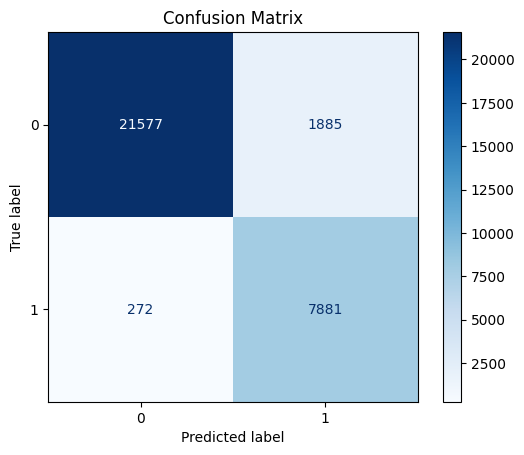

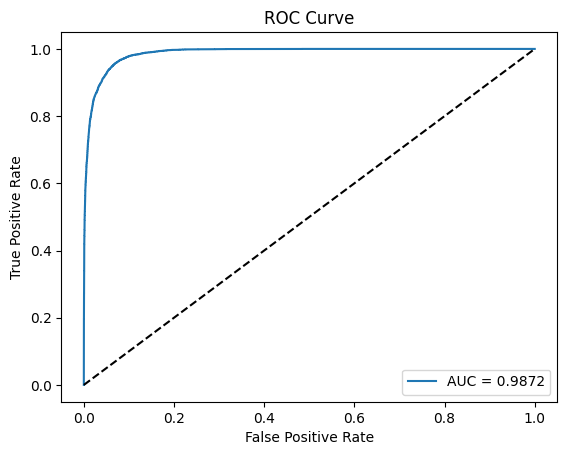

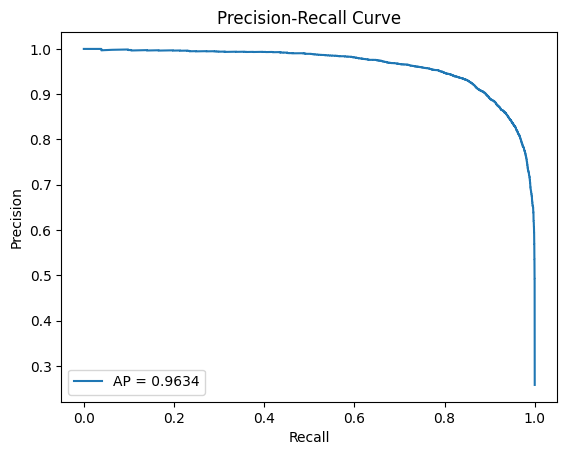

In [9]:
# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# Plot 3: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure()
plt.plot(recall, precision, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.show()

## 8. Feature Importance

duration_seconds    0.468599
topic               0.228057
country_region      0.090924
comment_rate        0.072819
like_rate           0.043778
view_count          0.037586
subscriber_count    0.036585
video_count         0.021652


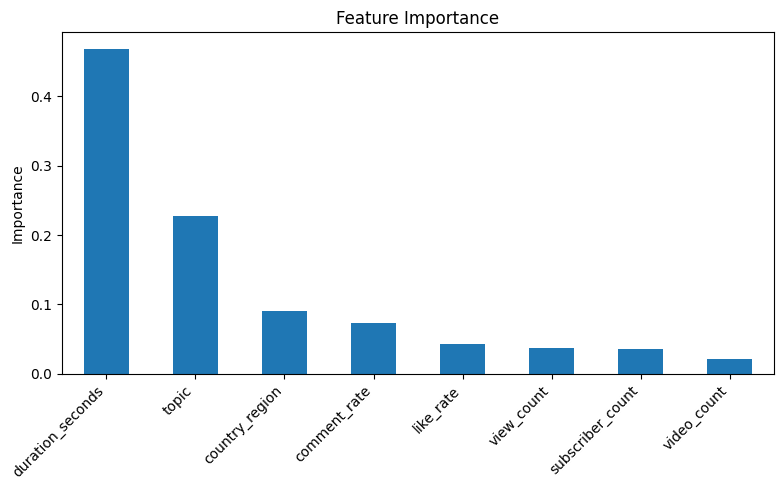

In [10]:
importances = model.feature_importances_
fi = pd.Series(importances, index=features).sort_values(ascending=False)

print(fi.to_string())

plt.figure(figsize=(8, 5))
fi.plot(kind="bar")
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9. Save Model

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

y_pred = model.predict(X_test)

print(f"\n=== Summary ===")
print(f"Features:   {len(features)}")
print(f"Train size: {len(X_train):,}")
print(f"Test size:  {len(X_test):,}")

print(f"Accuracy:   {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision:  {precision_score(y_test, y_pred):.4f}")
print(f"Recall:     {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:   {f1_score(y_test, y_pred):.4f}")

print(f"ROC-AUC:    {roc_auc_score(y_test, y_proba):.4f}")
print(f"Avg Prec:   {average_precision_score(y_test, y_proba):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))


=== Summary ===
Features:   8
Train size: 126,458
Test size:  31,615
Accuracy:   0.9318
Precision:  0.8070
Recall:     0.9666
F1-score:   0.8796
ROC-AUC:    0.9872
Avg Prec:   0.9634

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.99      0.92      0.95     23462
           1       0.81      0.97      0.88      8153

    accuracy                           0.93     31615
   macro avg       0.90      0.94      0.92     31615
weighted avg       0.94      0.93      0.93     31615


=== Confusion Matrix ===
[[21577  1885]
 [  272  7881]]
